<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/segyio_to_field_development_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From SEG-Y with segyio to field-development decisions with NeqSim

This intermediate, executable tutorial adapts the learning pattern from Equinor's
[`segyio` basic tutorial](https://github.com/equinor/segyio-notebooks/blob/master/notebooks/basic/01_basic_tutorial.ipynb):
read a 3-D SEG-Y cube, work on NumPy arrays, create a discontinuity/fault attribute,
overlay a mask, and write a derived volume back to SEG-Y.

The tutorial then follows those outputs into a transparent field-development chain:
structural interpretation, low/base/high in-place volumes, well and production screens,
NeqSim three-phase separation and export compression, facility capacity, and decision gates.

**Learning outcomes**

1. Create, read, inspect, and update a standards-shaped SEG-Y file with `segyio`.
2. Convert traces to a labelled amplitude cube without losing headers or units.
3. Calculate a screening discontinuity volume, fault mask, top and base surfaces.
4. Propagate depth conversion and rock-property uncertainty to STOIIP scenarios.
5. Translate selected facility loads into composable NeqSim process cases.
6. Explain what the result supports at DG0-DG4 and what must be handed to specialist tools.

## Engineering question, scope, and provenance

**Question:** How does work that starts as SEG-Y trace I/O become useful evidence for a
field-development decision without pretending that a seismic attribute is a reservoir
forecast?

The seismic volume, rock properties, fluid, wells, capacities, and economics in this
notebook are deterministic synthetic teaching data. Coordinates are local Cartesian
metres. Times are two-way time (TWT) in milliseconds; pressures are absolute; standard
volumes use NeqSim's standard state. The result is suitable for teaching and concept
screening, not reserves booking, well prognosis, facility design, or investment approval.

The source tutorial and `segyio` are LGPL-3.0 licensed. This notebook uses the public API
pattern and cites the tutorial; it does not copy the F3 data or its code. For a deeper
reservoir implementation, continue with
[`subsurface_data_to_opm_flow_production_forecast.ipynb`](../reservoir/subsurface_data_to_opm_flow_production_forecast.ipynb).

## Where each model belongs

| Stage | Evidence or model | Primary responsibility | Output used downstream |
|---|---|---|---|
| Seismic data | SEG-Y traces and headers | `segyio`, seismic processing and interpretation | amplitudes, geometry, horizons, faults, uncertainty |
| Static reservoir | depth conversion, contacts, facies, petrophysics | geomodelling and subsurface disciplines | grid, pore volume, properties, realizations |
| Dynamic reservoir | pressure, saturation, wells, controls | OPM Flow or another reservoir simulator | rates, pressure, GOR, water cut, uncertainty |
| Wells and SURF | inflow, lift, network, terrain, transients | well and multiphase-flow models | arrival pressure, temperature, phase loads |
| Facilities | fluid properties and process constraints | NeqSim process systems | products, duties, power, emissions, capacities |
| Decision | cost, schedule, risk, value | integrated field-development team | concept choice and data-acquisition plan |

The key rule is **handoff, not substitution**: `segyio` does not simulate a reservoir,
and NeqSim does not interpret seismic. The workflow keeps the realization identity and
uncertainty attached as information moves between disciplines.

In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
import os
from pathlib import Path
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
    "segyio": "1.9.14",
}
SUPPORT_PACKAGES = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
}


def installed_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return None


install_specs = [
    f"{name}=={required}"
    for name, required in REQUIRED_PACKAGES.items()
    if installed_version(name) != required
]
install_specs.extend(
    package
    for module, package in SUPPORT_PACKAGES.items()
    if importlib.util.find_spec(module) is None
)
if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
        timeout=900,
    )

os.environ.setdefault("MPLCONFIGDIR", "/tmp/segyio-field-development-matplotlib")
print("Dependency gate passed.")

Dependency gate passed.


In [2]:
import hashlib
import math
import platform
import shutil

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import segyio
from scipy.ndimage import gaussian_filter
from scipy.signal import fftconvolve, hilbert

from neqsim import jneqsim


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 115,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4g}")

RANDOM_SEED = 20_260_815
random_generator = np.random.default_rng(RANDOM_SEED)
OUTPUT_DIRECTORY = Path("segyio_field_development_outputs")
if OUTPUT_DIRECTORY.exists():
    shutil.rmtree(OUTPUT_DIRECTORY)
OUTPUT_DIRECTORY.mkdir()

StreamClass = jpype.JClass("neqsim.process.equipment.stream.Stream")
neqsim_package_root = Path(
    importlib.util.find_spec("neqsim").origin
).resolve().parent
neqsim_jars = sorted((neqsim_package_root / "lib").glob("neqsim-*.jar"))
if len(neqsim_jars) != 1:
    raise RuntimeError(
        f"Expected one bundled NeqSim JAR, found {len(neqsim_jars)}."
    )
neqsim_jar = neqsim_jars[0]
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()
active_classpath = jpype.getClassPath()
if str(neqsim_jar) not in active_classpath:
    raise RuntimeError("The bundled NeqSim JAR is not on the JPype classpath.")
loaded_class_name = str(StreamClass.class_.getName())
if loaded_class_name != "neqsim.process.equipment.stream.Stream":
    raise RuntimeError("The NeqSim Java smoke class did not load.")
java_class_source = (
    f"{neqsim_jar.name}; SHA-256 {neqsim_jar_sha256}"
)
runtime_versions = pd.DataFrame(
    {
        "runtime": [
            "Python",
            "Java",
            "neqsim",
            "segyio",
            "NumPy",
            "SciPy",
            "pandas",
            "Matplotlib",
            "NeqSim Java classes",
        ],
        "version or source": [
            platform.python_version(),
            jpype.getJVMVersion(),
            version("neqsim"),
            version("segyio"),
            version("numpy"),
            version("scipy"),
            version("pandas"),
            version("matplotlib"),
            java_class_source,
        ],
    }
)
display(runtime_versions)

,runtime,version or source
0,Python,3.12.13
1,Java,"(17, 0, 19)"
2,neqsim,3.17.0
3,segyio,1.9.14
4,NumPy,2.5.2
5,SciPy,1.18.0
6,pandas,3.0.5
7,Matplotlib,3.11.1
8,NeqSim Java classes,neqsim-3.17.0.jar; SHA-256 f114c17bf99a7b02be9...


## 1. Create a small faulted seismic volume

A deterministic acoustic-impedance model contains a channel-like low-impedance reservoir,
regional dip, a structural high, and a 28 ms normal-fault throw. Normal-incidence
reflectivity is calculated as

$$r_i=\frac{Z_{i+1}-Z_i}{Z_{i+1}+Z_i}$$

where $Z_i$ is acoustic impedance at sample $i$. A 28 Hz Ricker wavelet and weak seeded
noise make the result seismic-like. This deliberately transparent model provides known
top and base surfaces against which the interpretation can be checked.

In [3]:
inline_count = 41
crossline_count = 51
sample_count = 192
inline_spacing_m = 25.0
crossline_spacing_m = 25.0
sample_interval_ms = 4.0
first_sample_ms = 1_000.0

inline_x_m = np.arange(inline_count) * inline_spacing_m
crossline_y_m = np.arange(crossline_count) * crossline_spacing_m
sample_time_ms = (
    first_sample_ms
    + np.arange(sample_count) * sample_interval_ms
)
inline_grid_m, crossline_grid_m = np.meshgrid(
    inline_x_m,
    crossline_y_m,
    indexing="ij",
)

regional_dip_ms = (
    0.025 * inline_grid_m
    + 0.012 * crossline_grid_m
)
structural_high_ms = -42.0 * np.exp(
    -(
        (inline_grid_m - 430.0) ** 2 / (2.0 * 310.0**2)
        + (crossline_grid_m - 620.0) ** 2 / (2.0 * 360.0**2)
    )
)
fault_throw_ms = np.where(inline_grid_m > 520.0, 28.0, 0.0)
true_top_ms = (
    1_330.0
    + regional_dip_ms
    + structural_high_ms
    + fault_throw_ms
)
channel_axis_m = 620.0 + 90.0 * np.sin(inline_grid_m / 240.0)
channel_factor = np.exp(
    -((crossline_grid_m - channel_axis_m) / 180.0) ** 2
)
true_thickness_ms = 68.0 + 25.0 * channel_factor
true_base_ms = true_top_ms + true_thickness_ms

time_cube_ms = sample_time_ms[None, None, :]
reservoir_mask = (
    (time_cube_ms >= true_top_ms[:, :, None])
    & (time_cube_ms < true_base_ms[:, :, None])
)
reservoir_impedance = 6_500.0 + 300.0 * (1.0 - channel_factor)
impedance = np.full(
    (inline_count, crossline_count, sample_count),
    8_100.0,
)
impedance = np.where(
    reservoir_mask,
    reservoir_impedance[:, :, None],
    impedance,
)
impedance = np.where(
    time_cube_ms >= true_base_ms[:, :, None],
    8_500.0,
    impedance,
)

reflectivity = (
    impedance[:, :, 1:] - impedance[:, :, :-1]
) / (
    impedance[:, :, 1:] + impedance[:, :, :-1]
)
reflectivity = np.pad(reflectivity, ((0, 0), (0, 0), (0, 1)))
wavelet_time_s = np.arange(-64.0, 68.0, sample_interval_ms) / 1_000.0
wavelet_argument = np.pi * 28.0 * wavelet_time_s
wavelet = (
    1.0 - 2.0 * wavelet_argument**2
) * np.exp(-wavelet_argument**2)
amplitude_cube = fftconvolve(
    reflectivity,
    wavelet[None, None, :],
    mode="same",
    axes=2,
)
amplitude_cube = gaussian_filter(
    amplitude_cube,
    sigma=(0.35, 0.35, 0.0),
)
noise_scale = 0.025 * np.std(amplitude_cube)
amplitude_cube += noise_scale * random_generator.standard_normal(
    amplitude_cube.shape
)
amplitude_cube = amplitude_cube.astype("float32")

synthetic_summary = pd.DataFrame(
    {
        "quantity": [
            "cube shape",
            "TWT range",
            "sample interval",
            "inline spacing",
            "crossline spacing",
            "fault throw",
        ],
        "value": [
            str(amplitude_cube.shape),
            f"{sample_time_ms.min():.0f}-{sample_time_ms.max():.0f}",
            sample_interval_ms,
            inline_spacing_m,
            crossline_spacing_m,
            28.0,
        ],
        "unit": ["samples", "ms", "ms", "m", "m", "ms"],
    }
)
display(synthetic_summary)

,quantity,value,unit
0,cube shape,"(41, 51, 192)",samples
1,TWT range,1000-1764,ms
2,sample interval,4,ms
3,inline spacing,25,m
4,crossline spacing,25,m
5,fault throw,28,ms


## 2. Write and read SEG-Y with headers intact

`segyio.tools.from_array3D` writes an inline-major post-stack cube. The notebook then adds
local source coordinates to every trace header. A reusable reader returns the NumPy cube,
inline and crossline labels, samples, binary-header interval, and selected trace headers.

In a real project, first audit the SEG-Y revision, sample format, geometry, scalar signs,
coordinate reference system, processing history, amplitude convention, and survey merge.
Do not assume that every file is regular, post-stack, inline-major, or depth converted.

In [4]:
input_segy_path = OUTPUT_DIRECTORY / "synthetic_faulted_amplitude.sgy"
segyio.tools.from_array3D(
    str(input_segy_path),
    amplitude_cube,
    dt=int(sample_interval_ms * 1_000.0),
    delrt=int(first_sample_ms),
)

with segyio.open(str(input_segy_path), "r+", strict=True) as segy_file:
    for trace_index in range(segy_file.tracecount):
        inline_index = trace_index // crossline_count
        crossline_index = trace_index % crossline_count
        trace_header = segy_file.header[trace_index]
        trace_header[segyio.TraceField.SourceX] = int(
            inline_x_m[inline_index]
        )
        trace_header[segyio.TraceField.SourceY] = int(
            crossline_y_m[crossline_index]
        )


def read_segy_cube(path):
    with segyio.open(str(path), "r", strict=True) as segy_file:
        segy_file.mmap()
        cube = segyio.tools.cube(segy_file).copy()
        headers = {
            "source_x_first": int(
                segy_file.header[0][segyio.TraceField.SourceX]
            ),
            "source_y_first": int(
                segy_file.header[0][segyio.TraceField.SourceY]
            ),
            "source_x_last": int(
                segy_file.header[-1][segyio.TraceField.SourceX]
            ),
            "source_y_last": int(
                segy_file.header[-1][segyio.TraceField.SourceY]
            ),
        }
        return {
            "cube": cube,
            "ilines": segy_file.ilines.copy(),
            "xlines": segy_file.xlines.copy(),
            "samples_ms": segy_file.samples.copy(),
            "sample_interval_us": int(
                segy_file.bin[segyio.BinField.Interval]
            ),
            "trace_count": int(segy_file.tracecount),
            "headers": headers,
        }


input_segy = read_segy_cube(input_segy_path)
seismic_cube = input_segy["cube"]
input_roundtrip_error = float(
    np.max(np.abs(seismic_cube - amplitude_cube))
)
segy_audit = pd.DataFrame(
    {
        "check": [
            "trace count",
            "inline labels",
            "crossline labels",
            "sample interval",
            "amplitude round-trip maximum error",
            "file size",
        ],
        "value": [
            input_segy["trace_count"],
            input_segy["ilines"].size,
            input_segy["xlines"].size,
            input_segy["sample_interval_us"],
            input_roundtrip_error,
            input_segy_path.stat().st_size / 1.0e6,
        ],
        "unit": ["traces", "count", "count", "µs", "-", "MB"],
    }
)
display(segy_audit)
display(pd.DataFrame([input_segy["headers"]]))

,check,value,unit
0,trace count,"2,091",traces
1,inline labels,41,count
2,crossline labels,51,count
3,sample interval,"4,000",µs
4,amplitude round-trip maximum error,0,-
5,file size,2.111,MB


,source_x_first,source_y_first,source_x_last,source_y_last
0,0,0,1000,1250


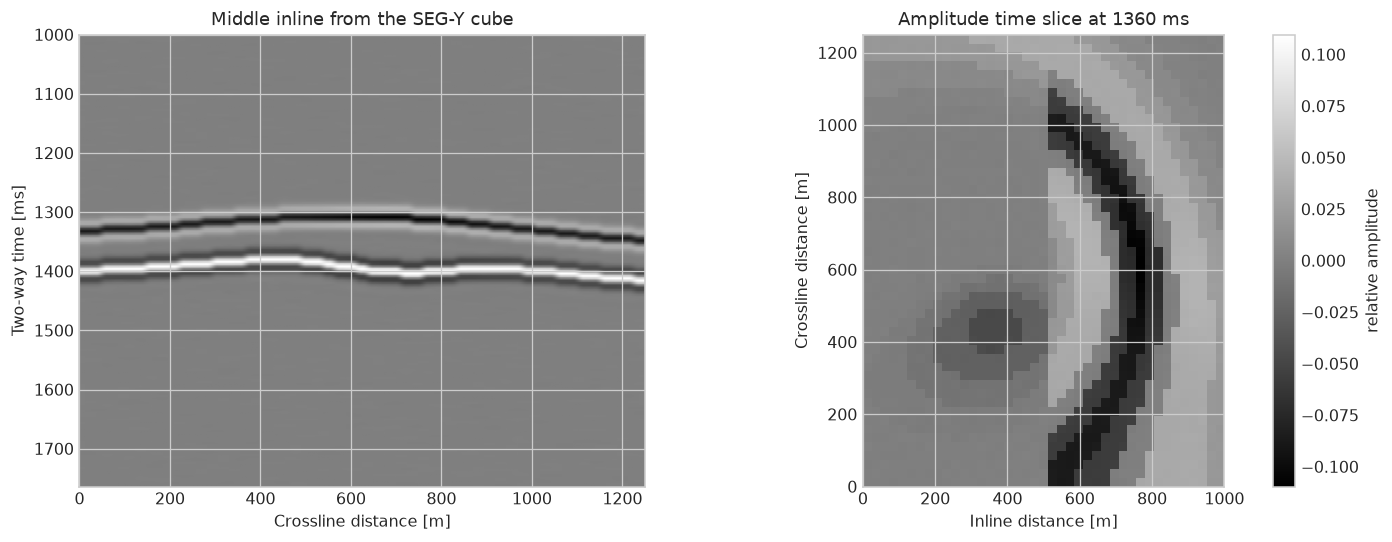

In [5]:
middle_inline_index = inline_count // 2
display_time_ms = 1_360.0
display_sample_index = int(
    np.argmin(np.abs(input_segy["samples_ms"] - display_time_ms))
)

quicklook_figure, quicklook_axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.6),
    constrained_layout=True,
)
amplitude_limit = np.quantile(np.abs(seismic_cube), 0.995)
quicklook_axes[0].imshow(
    seismic_cube[middle_inline_index].T,
    aspect="auto",
    cmap="gray",
    vmin=-amplitude_limit,
    vmax=amplitude_limit,
    extent=[
        crossline_y_m.min(),
        crossline_y_m.max(),
        sample_time_ms.max(),
        sample_time_ms.min(),
    ],
)
quicklook_axes[0].set(
    xlabel="Crossline distance [m]",
    ylabel="Two-way time [ms]",
    title="Middle inline from the SEG-Y cube",
)
time_slice = quicklook_axes[1].imshow(
    seismic_cube[:, :, display_sample_index].T,
    origin="lower",
    cmap="gray",
    vmin=-amplitude_limit,
    vmax=amplitude_limit,
    extent=[
        inline_x_m.min(),
        inline_x_m.max(),
        crossline_y_m.min(),
        crossline_y_m.max(),
    ],
    aspect="equal",
)
quicklook_axes[1].set(
    xlabel="Inline distance [m]",
    ylabel="Crossline distance [m]",
    title=f"Amplitude time slice at {display_time_ms:.0f} ms",
)
quicklook_figure.colorbar(
    time_slice,
    ax=quicklook_axes[1],
    label="relative amplitude",
)
quicklook_path = OUTPUT_DIRECTORY / "01_segy_quicklook.png"
quicklook_figure.savefig(quicklook_path, dpi=170)
plt.show()

**Figure discussion — SEG-Y quick look.** Observation: the middle inline spans
1,000-1,764 ms TWT and the 1,360 ms slice shows a laterally continuous reservoir event
interrupted near local inline X = 520 m. Mechanism: the imposed fault moves both top and
base reflectors by seven samples, while the structural high and channel change event time
and amplitude smoothly. Engineering implication: geometry and processing assumptions must
be verified before attribute thresholds are interpreted as compartments. Recommendation:
review inline, crossline, time/depth slices, headers, well ties, and processing provenance
together before creating a fault framework.

## 3. Repeat the basic tutorial pattern: cube → attribute → mask → SEG-Y

The analytic-signal envelope is differentiated in the two lateral directions. The
normalized gradient magnitude is used as a transparent discontinuity indicator $D$ and
the tutorial-style similarity is $S=1-D$. Values above 0.62 form a screening fault mask.

This is deliberately **not** a production fault-segmentation algorithm. It demonstrates
array manipulation and file round-trip. Real interpretation normally uses conditioned
seismic, multiple attributes, structural steering, uncertainty, and expert review.

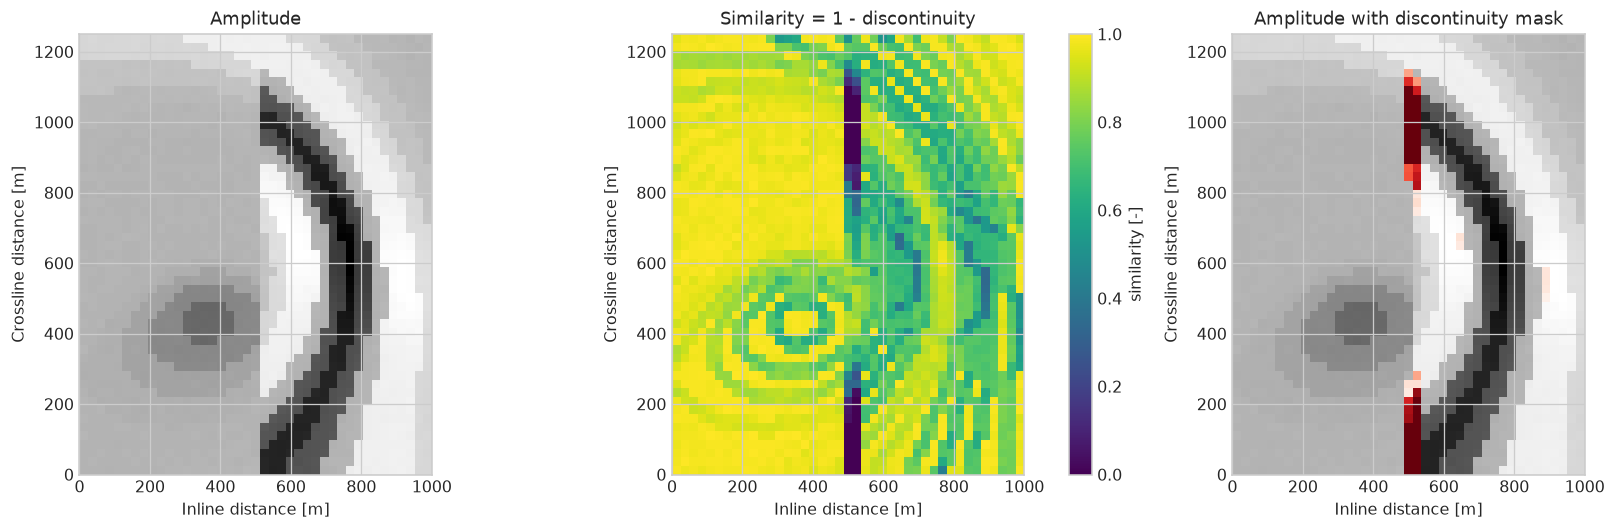

In [6]:
envelope_cube = np.abs(hilbert(seismic_cube, axis=2))
envelope_inline_gradient = np.gradient(envelope_cube, axis=0)
envelope_crossline_gradient = np.gradient(envelope_cube, axis=1)
lateral_gradient = np.hypot(
    envelope_inline_gradient,
    envelope_crossline_gradient,
)
discontinuity_scale = np.quantile(lateral_gradient, 0.995)
discontinuity_cube = np.clip(
    lateral_gradient / discontinuity_scale,
    0.0,
    1.0,
).astype("float32")
similarity_cube = 1.0 - discontinuity_cube
fault_threshold = 0.62
fault_mask = np.ma.masked_where(
    discontinuity_cube < fault_threshold,
    discontinuity_cube,
)

attribute_figure, attribute_axes = plt.subplots(
    1,
    3,
    figsize=(14.5, 4.5),
    constrained_layout=True,
)
attribute_axes[0].imshow(
    seismic_cube[:, :, display_sample_index].T,
    origin="lower",
    cmap="gray",
    extent=[0.0, inline_x_m.max(), 0.0, crossline_y_m.max()],
    aspect="equal",
)
attribute_axes[0].set_title("Amplitude")
similarity_image = attribute_axes[1].imshow(
    similarity_cube[:, :, display_sample_index].T,
    origin="lower",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    extent=[0.0, inline_x_m.max(), 0.0, crossline_y_m.max()],
    aspect="equal",
)
attribute_axes[1].set_title("Similarity = 1 - discontinuity")
attribute_figure.colorbar(
    similarity_image,
    ax=attribute_axes[1],
    label="similarity [-]",
)
attribute_axes[2].imshow(
    seismic_cube[:, :, display_sample_index].T,
    origin="lower",
    cmap="gray",
    extent=[0.0, inline_x_m.max(), 0.0, crossline_y_m.max()],
    aspect="equal",
)
attribute_axes[2].imshow(
    fault_mask[:, :, display_sample_index].T,
    origin="lower",
    cmap="Reds",
    vmin=fault_threshold,
    vmax=1.0,
    extent=[0.0, inline_x_m.max(), 0.0, crossline_y_m.max()],
    aspect="equal",
)
attribute_axes[2].set_title("Amplitude with discontinuity mask")
for axis in attribute_axes:
    axis.set_xlabel("Inline distance [m]")
    axis.set_ylabel("Crossline distance [m]")
attribute_path = OUTPUT_DIRECTORY / "02_attribute_and_fault_mask.png"
attribute_figure.savefig(attribute_path, dpi=170)
plt.show()

**Figure discussion — discontinuity screening.** Observation: the red mask concentrates
along the synthetic fault but also appears at strong lateral amplitude changes; similarity
remains near one in laterally uniform areas. Mechanism: a lateral envelope gradient responds
to both displacement and stratigraphic amplitude change. Engineering implication: a binary
mask is evidence for review, not a transmissibility multiplier or sealed-fault declaration.
Recommendation: carry alternative thresholds and interpreter scenarios into the structural
ensemble, then condition fault properties to pressure, contacts, well tests, and production.

In [7]:
output_segy_path = OUTPUT_DIRECTORY / "synthetic_discontinuity.sgy"
shutil.copy2(input_segy_path, output_segy_path)
with segyio.open(str(output_segy_path), "r+", strict=True) as output_file:
    for trace_index in range(output_file.tracecount):
        inline_index = trace_index // crossline_count
        crossline_index = trace_index % crossline_count
        output_file.trace[trace_index] = discontinuity_cube[
            inline_index,
            crossline_index,
        ]

output_segy = read_segy_cube(output_segy_path)
discontinuity_roundtrip_error = float(
    np.max(
        np.abs(
            output_segy["cube"]
            - discontinuity_cube
        )
    )
)
header_contract = {
    "trace count retained": (
        output_segy["trace_count"] == input_segy["trace_count"]
    ),
    "inline labels retained": np.array_equal(
        output_segy["ilines"],
        input_segy["ilines"],
    ),
    "crossline labels retained": np.array_equal(
        output_segy["xlines"],
        input_segy["xlines"],
    ),
    "sample interval retained": (
        output_segy["sample_interval_us"]
        == input_segy["sample_interval_us"]
    ),
    "coordinate endpoints retained": (
        output_segy["headers"] == input_segy["headers"]
    ),
}
output_audit = pd.DataFrame(
    {
        "check": [
            *header_contract.keys(),
            "discontinuity amplitude round-trip",
            "output SHA-256",
        ],
        "result": [
            *header_contract.values(),
            discontinuity_roundtrip_error,
            hashlib.sha256(output_segy_path.read_bytes()).hexdigest(),
        ],
    }
)
display(output_audit)

,check,result
0,trace count retained,True
1,inline labels retained,True
2,crossline labels retained,True
3,sample interval retained,True
4,coordinate endpoints retained,True
5,discontinuity amplitude round-trip,0
6,output SHA-256,2a2c748e59568f2bb4794aa324437cde4879aba919a93c...


## 4. Interpret top, base, thickness, and fault evidence

The picker searches for the negative top event and positive base event within reviewed
windows. TWT is converted to depth using a constant screening velocity $v$:

$$z=\frac{v\,t_{\mathrm{TWT}}}{2}$$

The constant 2,800 m/s velocity is an educational assumption. A development study requires
checkshots/VSP, anisotropy, lateral velocity variation, processing datum, uncertainty, and
consistent TVDSS sign convention. The known synthetic surfaces provide an independent
interpretation error check that would not exist for field data.

In [8]:
top_window = (
    (sample_time_ms >= 1_240.0)
    & (sample_time_ms <= 1_490.0)
)
top_window_start = int(np.flatnonzero(top_window)[0])
picked_top_index = (
    np.argmin(seismic_cube[:, :, top_window], axis=2)
    + top_window_start
)

base_window = (
    (sample_time_ms >= 1_340.0)
    & (sample_time_ms <= 1_630.0)
)
base_window_start = int(np.flatnonzero(base_window)[0])
base_window_stop = int(np.flatnonzero(base_window)[-1])
picked_base_index = np.empty(
    (inline_count, crossline_count),
    dtype=int,
)
for inline_index in range(inline_count):
    for crossline_index in range(crossline_count):
        search_start = max(
            picked_top_index[inline_index, crossline_index] + 8,
            base_window_start,
        )
        local_trace = seismic_cube[
            inline_index,
            crossline_index,
            search_start : base_window_stop + 1,
        ]
        picked_base_index[inline_index, crossline_index] = (
            search_start + int(np.argmax(local_trace))
        )

interpreted_top_ms = sample_time_ms[picked_top_index]
interpreted_base_ms = sample_time_ms[picked_base_index]
interpreted_thickness_ms = interpreted_base_ms - interpreted_top_ms
top_pick_rmse_ms = float(
    np.sqrt(np.mean((interpreted_top_ms - true_top_ms) ** 2))
)
thickness_pick_rmse_ms = float(
    np.sqrt(
        np.mean(
            (
                interpreted_thickness_ms
                - true_thickness_ms
            )
            ** 2
        )
    )
)

screening_velocity_m_s = 2_800.0
interpreted_top_depth_m = (
    interpreted_top_ms * screening_velocity_m_s / 2_000.0
)
interpreted_thickness_m = (
    interpreted_thickness_ms
    * screening_velocity_m_s
    / 2_000.0
)
fault_evidence_map = np.max(
    discontinuity_cube[:, :, top_window],
    axis=2,
)
interpretation_audit = pd.DataFrame(
    {
        "metric": [
            "top pick RMSE",
            "thickness pick RMSE",
            "interpreted top-depth range",
            "mean interpreted thickness",
        ],
        "value": [
            top_pick_rmse_ms,
            thickness_pick_rmse_ms,
            interpreted_top_depth_m.max()
            - interpreted_top_depth_m.min(),
            interpreted_thickness_m.mean(),
        ],
        "unit": ["ms", "ms", "m", "m"],
    }
)
display(interpretation_audit)

,metric,value,unit
0,top pick RMSE,2.313,ms
1,thickness pick RMSE,1.286,ms
2,interpreted top-depth range,128.8,m
3,mean interpreted thickness,104,m


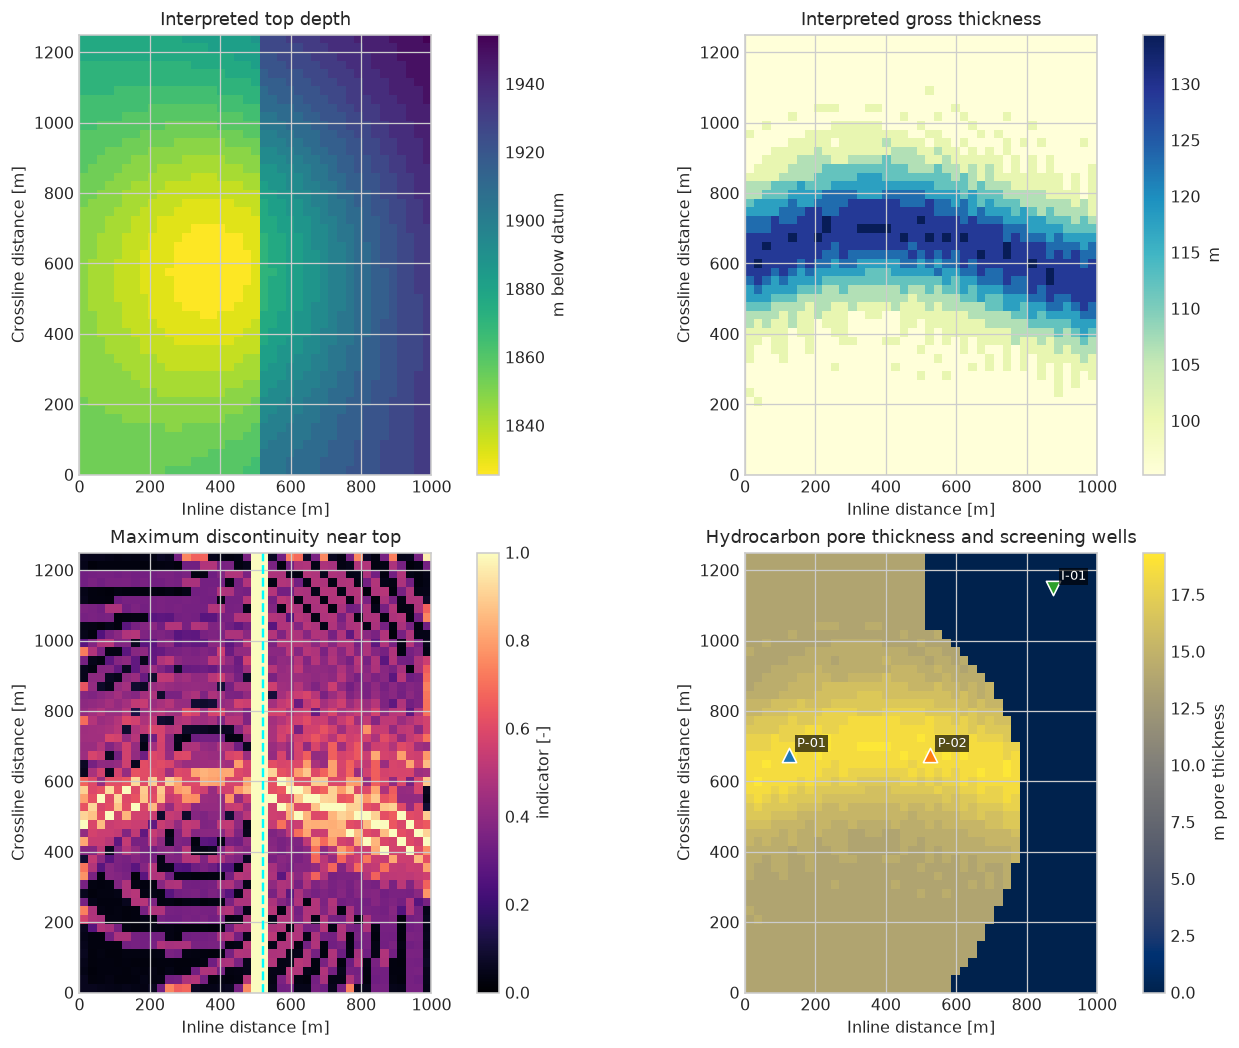

,well,role,inline index,crossline index,x_m,y_m
0,P-01,producer,5,27,125,675
1,P-02,producer,21,27,525,675
2,I-01,water injector,35,46,875,"1,150"


In [9]:
base_closure_mask = interpreted_top_depth_m < np.quantile(
    interpreted_top_depth_m,
    0.70,
)
hydrocarbon_pore_thickness = (
    interpreted_thickness_m
    * base_closure_mask
    * 0.75
    * 0.24
    * (1.0 - 0.20)
)
left_compartment = inline_grid_m <= 520.0
right_compartment = ~left_compartment
interior_cells = (
    (inline_grid_m >= 100.0)
    & (inline_grid_m <= 900.0)
    & (crossline_grid_m >= 100.0)
    & (crossline_grid_m <= 1_150.0)
)


def maximum_location(score, allowed):
    allowed_score = np.where(allowed, score, -np.inf)
    return np.unravel_index(
        int(np.argmax(allowed_score)),
        allowed_score.shape,
    )


producer_left = maximum_location(
    hydrocarbon_pore_thickness,
    left_compartment & interior_cells,
)
producer_right = maximum_location(
    hydrocarbon_pore_thickness,
    right_compartment & interior_cells,
)
injector_location = np.unravel_index(
    int(
        np.argmax(
            np.where(
                interior_cells,
                interpreted_top_depth_m,
                -np.inf,
            )
        )
    ),
    interpreted_top_depth_m.shape,
)
well_plan = pd.DataFrame(
    [
        ("P-01", "producer", *producer_left),
        ("P-02", "producer", *producer_right),
        ("I-01", "water injector", *injector_location),
    ],
    columns=["well", "role", "inline index", "crossline index"],
)
well_plan["x_m"] = well_plan["inline index"].map(
    lambda index: inline_x_m[int(index)]
)
well_plan["y_m"] = well_plan["crossline index"].map(
    lambda index: crossline_y_m[int(index)]
)

interpretation_figure, interpretation_axes = plt.subplots(
    2,
    2,
    figsize=(11.5, 9.0),
    constrained_layout=True,
)
map_extent = [0.0, inline_x_m.max(), 0.0, crossline_y_m.max()]
top_image = interpretation_axes[0, 0].imshow(
    interpreted_top_depth_m.T,
    origin="lower",
    extent=map_extent,
    cmap="viridis_r",
    aspect="equal",
)
interpretation_axes[0, 0].set_title("Interpreted top depth")
interpretation_figure.colorbar(
    top_image,
    ax=interpretation_axes[0, 0],
    label="m below datum",
)
thickness_image = interpretation_axes[0, 1].imshow(
    interpreted_thickness_m.T,
    origin="lower",
    extent=map_extent,
    cmap="YlGnBu",
    aspect="equal",
)
interpretation_axes[0, 1].set_title("Interpreted gross thickness")
interpretation_figure.colorbar(
    thickness_image,
    ax=interpretation_axes[0, 1],
    label="m",
)
fault_image = interpretation_axes[1, 0].imshow(
    fault_evidence_map.T,
    origin="lower",
    extent=map_extent,
    cmap="magma",
    vmin=0.0,
    vmax=1.0,
    aspect="equal",
)
interpretation_axes[1, 0].axvline(
    520.0,
    color="cyan",
    linestyle="--",
)
interpretation_axes[1, 0].set_title("Maximum discontinuity near top")
interpretation_figure.colorbar(
    fault_image,
    ax=interpretation_axes[1, 0],
    label="indicator [-]",
)
hcpv_image = interpretation_axes[1, 1].imshow(
    hydrocarbon_pore_thickness.T,
    origin="lower",
    extent=map_extent,
    cmap="cividis",
    aspect="equal",
)
for _, well in well_plan.iterrows():
    marker = "^" if well["role"] == "producer" else "v"
    interpretation_axes[1, 1].scatter(
        well["x_m"],
        well["y_m"],
        marker=marker,
        s=80,
        edgecolor="white",
    )
    interpretation_axes[1, 1].annotate(
        well["well"],
        (well["x_m"], well["y_m"]),
        xytext=(5, 5),
        textcoords="offset points",
        color="white",
        fontsize=8,
        bbox={
            "facecolor": "black",
            "edgecolor": "none",
            "alpha": 0.65,
            "pad": 1.5,
        },
    )
interpretation_axes[1, 1].set_title(
    "Hydrocarbon pore thickness and screening wells"
)
interpretation_figure.colorbar(
    hcpv_image,
    ax=interpretation_axes[1, 1],
    label="m pore thickness",
)
for axis in interpretation_axes.flat:
    axis.set_xlabel("Inline distance [m]")
    axis.set_ylabel("Crossline distance [m]")
interpretation_path = OUTPUT_DIRECTORY / "03_interpretation_and_wells.png"
interpretation_figure.savefig(interpretation_path, dpi=170)
plt.show()
display(well_plan)

**Figure discussion — interpretation and well screen.** Observation: the deterministic
picker recovers top and thickness with errors below one 4 ms sample, while the 28 ms fault
separates two structural compartments. Mechanism: event polarity and reviewed search
windows stabilize the synthetic pick; depth structure still scales directly with the
assumed velocity. Engineering implication: the apparent two-producer layout depends on
fault communication, contacts, rock quality, pressure support, and drilling constraints
not resolved by the amplitude cube. Recommendation: use the map to design appraisal and
dynamic-model cases, not to freeze well coordinates.

## 5. Propagate interpretation uncertainty to in-place volumes

For cell area $A_i$, gross thickness $h_i$, net-to-gross $N_i$, porosity $\phi_i$,
water saturation $S_{w,i}$, and oil formation-volume factor $B_o$,

$$\mathrm{STOIIP}=\sum_i\frac{A_i h_i N_i\phi_i(1-S_{w,i})}{B_o}$$

Low/base/high scenarios vary velocity, thickness, closure, net-to-gross, porosity,
saturation, and $B_o$ together. These are coherent teaching scenarios, not statistical
reserves categories. In a real study they would be realizations tied to named seismic,
depth-conversion, contact, petrophysical, SCAL, and PVT evidence.

In [10]:
cell_area_m2 = inline_spacing_m * crossline_spacing_m
scenario_definitions = pd.DataFrame(
    [
        ("LOW", 0.96, 0.90, 0.60, 0.65, 0.20, 0.28, 1.30, 0.28),
        ("BASE", 1.00, 1.00, 0.70, 0.75, 0.24, 0.20, 1.25, 0.34),
        ("HIGH", 1.04, 1.10, 0.80, 0.82, 0.27, 0.16, 1.20, 0.40),
    ],
    columns=[
        "scenario",
        "velocity multiplier",
        "thickness multiplier",
        "closure quantile",
        "NTG",
        "porosity",
        "water saturation",
        "Bo rm3/Sm3",
        "recovery factor",
    ],
)

volumetric_records = []
for _, scenario in scenario_definitions.iterrows():
    scenario_top_depth_m = (
        interpreted_top_depth_m
        * scenario["velocity multiplier"]
    )
    scenario_thickness_m = (
        interpreted_thickness_m
        * scenario["velocity multiplier"]
        * scenario["thickness multiplier"]
    )
    spill_depth_m = np.quantile(
        scenario_top_depth_m,
        scenario["closure quantile"],
    )
    closure_mask = scenario_top_depth_m <= spill_depth_m
    gross_rock_volume_m3 = (
        np.sum(scenario_thickness_m[closure_mask])
        * cell_area_m2
    )
    stoiip_sm3 = (
        gross_rock_volume_m3
        * scenario["NTG"]
        * scenario["porosity"]
        * (1.0 - scenario["water saturation"])
        / scenario["Bo rm3/Sm3"]
    )
    recoverable_sm3 = stoiip_sm3 * scenario["recovery factor"]
    volumetric_records.append(
        {
            "scenario": scenario["scenario"],
            "spill depth m": spill_depth_m,
            "closure cells": int(np.sum(closure_mask)),
            "GRV Mm3": gross_rock_volume_m3 / 1.0e6,
            "STOIIP MSm3": stoiip_sm3 / 1.0e6,
            "recovery factor": scenario["recovery factor"],
            "recoverable MSm3": recoverable_sm3 / 1.0e6,
        }
    )

volumetric_scenarios = pd.DataFrame(volumetric_records)
display(volumetric_scenarios)

,scenario,spill depth m,closure cells,GRV Mm3,STOIIP MSm3,recovery factor,recoverable MSm3
0,LOW,"1,817",1264,71.81,5.171,0.28,1.448
1,BASE,"1,910",1520,99.82,11.5,0.34,3.91
2,HIGH,"1,998",1730,129.6,20.08,0.4,8.032


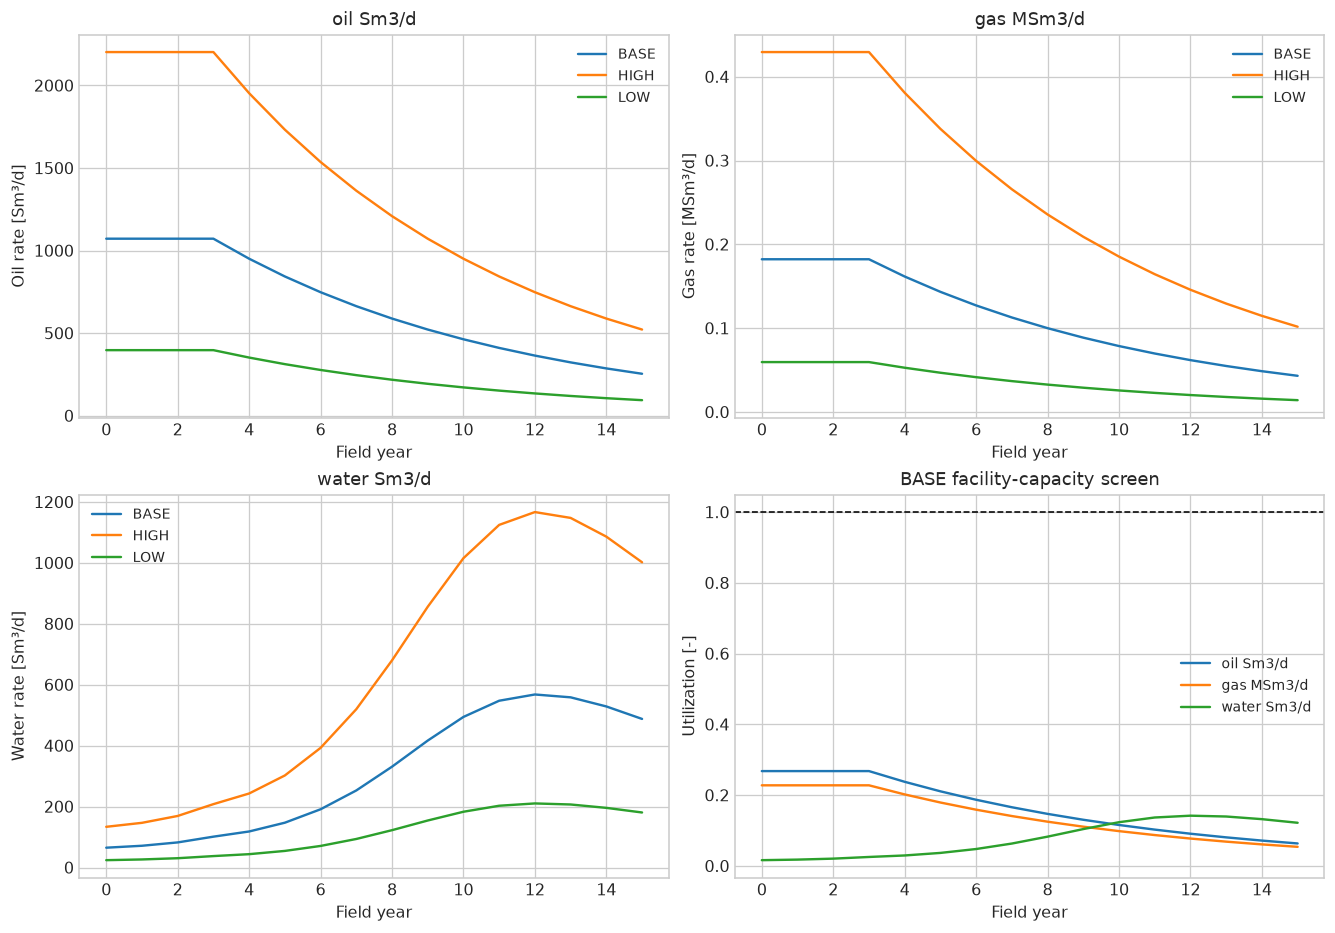

,scenario,year,oil Sm3/d,gas MSm3/d,water Sm3/d,maximum utilization,active facility constraint
0,LOW,0,397,0.05955,24.08,0.09924,oil Sm3/d
5,LOW,5,312.3,0.04684,54.46,0.07807,oil Sm3/d
10,LOW,10,171.4,0.02571,183,0.04576,water Sm3/d
15,LOW,15,94.05,0.01411,180.6,0.04515,water Sm3/d
16,BASE,0,"1,072",0.1822,65.03,0.268,oil Sm3/d
21,BASE,5,843.3,0.1434,147.1,0.2108,oil Sm3/d
26,BASE,10,462.8,0.07867,494.3,0.1236,water Sm3/d
31,BASE,15,254,0.04318,487.7,0.1219,water Sm3/d
32,HIGH,0,"2,202",0.4294,133.6,0.5506,oil Sm3/d
37,HIGH,5,"1,732",0.3378,302.1,0.4331,oil Sm3/d


In [11]:
field_years = np.arange(0, 16)
forecast_records = []
facility_limits = {
    "oil Sm3/d": 4_000.0,
    "gas MSm3/d": 0.80,
    "water Sm3/d": 4_000.0,
}
scenario_gor_sm3_sm3 = {
    "LOW": 150.0,
    "BASE": 170.0,
    "HIGH": 195.0,
}
for _, scenario in volumetric_scenarios.iterrows():
    scenario_name = scenario["scenario"]
    recoverable_sm3 = scenario["recoverable MSm3"] * 1.0e6
    unconstrained_plateau = 1.5 * recoverable_sm3 / (7.0 * 365.25)
    plateau_oil_sm3_d = min(
        unconstrained_plateau,
        facility_limits["oil Sm3/d"],
    )
    decline_time = np.maximum(field_years - 3.0, 0.0)
    oil_rate_sm3_d = plateau_oil_sm3_d * np.exp(
        -0.12 * decline_time
    )
    cumulative_oil_sm3 = np.cumsum(oil_rate_sm3_d * 365.25)
    scale_to_recovery = min(
        1.0,
        recoverable_sm3 / cumulative_oil_sm3[-1],
    )
    oil_rate_sm3_d *= scale_to_recovery
    water_cut = 0.05 + 0.62 / (
        1.0 + np.exp(-(field_years - 8.0) / 1.8)
    )
    water_rate_sm3_d = (
        oil_rate_sm3_d
        * water_cut
        / np.maximum(1.0 - water_cut, 0.05)
    )
    gas_rate_msm3_d = (
        oil_rate_sm3_d
        * scenario_gor_sm3_sm3[scenario_name]
        / 1.0e6
    )
    for year_index, year in enumerate(field_years):
        forecast_records.append(
            {
                "scenario": scenario_name,
                "year": int(year),
                "oil Sm3/d": oil_rate_sm3_d[year_index],
                "gas MSm3/d": gas_rate_msm3_d[year_index],
                "water Sm3/d": water_rate_sm3_d[year_index],
                "water cut": water_cut[year_index],
            }
        )

field_forecast = pd.DataFrame(forecast_records)
for service, limit in facility_limits.items():
    field_forecast[f"{service} utilization"] = (
        field_forecast[service] / limit
    )
utilization_columns = [
    f"{service} utilization"
    for service in facility_limits
]
field_forecast["maximum utilization"] = field_forecast[
    utilization_columns
].max(axis=1)
field_forecast["active facility constraint"] = field_forecast[
    utilization_columns
].idxmax(axis=1).str.replace(" utilization", "")

forecast_figure, forecast_axes = plt.subplots(
    2,
    2,
    figsize=(11.5, 8.0),
    constrained_layout=True,
)
forecast_specs = [
    ("oil Sm3/d", "Oil rate [Sm³/d]"),
    ("gas MSm3/d", "Gas rate [MSm³/d]"),
    ("water Sm3/d", "Water rate [Sm³/d]"),
]
for axis, (column, label) in zip(
    forecast_axes.flat[:3],
    forecast_specs,
):
    for scenario_name, group in field_forecast.groupby("scenario"):
        axis.plot(group["year"], group[column], label=scenario_name)
    axis.set(xlabel="Field year", ylabel=label, title=column)
    axis.legend()
for column in utilization_columns:
    forecast_axes[1, 1].plot(
        field_forecast.query("scenario == 'BASE'")["year"],
        field_forecast.query("scenario == 'BASE'")[column],
        label=column.replace(" utilization", ""),
    )
forecast_axes[1, 1].axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.0,
)
forecast_axes[1, 1].set(
    xlabel="Field year",
    ylabel="Utilization [-]",
    title="BASE facility-capacity screen",
)
forecast_axes[1, 1].legend()
forecast_path = OUTPUT_DIRECTORY / "04_forecast_and_capacity.png"
forecast_figure.savefig(forecast_path, dpi=170)
plt.show()

forecast_summary = field_forecast.query(
    "year in [0, 5, 10, 15]"
)[
    [
        "scenario",
        "year",
        "oil Sm3/d",
        "gas MSm3/d",
        "water Sm3/d",
        "maximum utilization",
        "active facility constraint",
    ]
]
display(forecast_summary)

**Figure discussion — reservoir-to-facility screen.** Observation: the coherent scenarios
preserve ordered oil and gas forecasts, while water load grows after the plateau and can
replace oil or gas as the active facility constraint. Mechanism: in-place volume and
recovery determine recoverable production, whereas water-cut growth changes total-liquid
handling even as oil declines. Engineering implication: a single peak-rate case cannot
size the whole field life. Recommendation: send named low/base/high dynamic realizations
to wells, SURF, process, water handling, power, emissions, and economics together.

## 6. Translate selected loads into a NeqSim process handoff

NeqSim does not consume the seismic cube. It receives a documented fluid and selected
well/SURF arrival cases. The example uses `SystemSrkCPAstatoil` with CPA mixing rule 10,
a `Stream`, `ThreePhaseSeparator`, gas `Compressor`, and `ProcessSystem`. The synthetic
composition contains hydrocarbons and water; separator product streams remain named for
downstream integration.

This is a composable process-capacity screen. A project model needs tuned PVT, heavy-end
characterization, measured water chemistry, arrival states from multiphase hydraulics,
recycle, heat integration, equipment maps, control, relief, emissions, and turndown.

In [12]:
SystemSrkCPA = jneqsim.thermo.system.SystemSrkCPAstatoil
Stream = jneqsim.process.equipment.stream.Stream
ThreePhaseSeparator = (
    jneqsim.process.equipment.separator.ThreePhaseSeparator
)
Compressor = jneqsim.process.equipment.compressor.Compressor
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

process_feed_composition = {
    "methane": 48.0,
    "ethane": 6.0,
    "propane": 4.0,
    "n-heptane": 20.0,
    "nC10": 12.0,
    "water": 10.0,
}


def make_process_fluid():
    fluid = SystemSrkCPA(273.15 + 72.0, 65.0)
    for component, amount in process_feed_composition.items():
        fluid.addComponent(component, amount)
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    return fluid


def run_process_case(scenario_name, feed_rate_kg_h):
    wellstream = Stream(
        f"{scenario_name} field inlet",
        make_process_fluid(),
    )
    wellstream.setFlowRate(float(feed_rate_kg_h), "kg/hr")
    separator = ThreePhaseSeparator(
        f"{scenario_name} HP separator",
        wellstream,
    )
    compressor = Compressor(
        f"{scenario_name} export compressor",
        separator.getGasOutStream(),
    )
    compressor.setOutletPressure(125.0)
    compressor.setIsentropicEfficiency(0.78)
    process = ProcessSystem()
    process.add(wellstream)
    process.add(separator)
    process.add(compressor)
    process.run()

    gas_rate_kg_h = float(
        separator.getGasOutStream().getFlowRate("kg/hr")
    )
    oil_rate_kg_h = float(
        separator.getOilOutStream().getFlowRate("kg/hr")
    )
    water_rate_kg_h = float(
        separator.getWaterOutStream().getFlowRate("kg/hr")
    )
    total_products_kg_h = (
        gas_rate_kg_h + oil_rate_kg_h + water_rate_kg_h
    )
    mass_residual = abs(
        total_products_kg_h - feed_rate_kg_h
    ) / feed_rate_kg_h
    return {
        "scenario": scenario_name,
        "feed kg/h": feed_rate_kg_h,
        "gas kg/h": gas_rate_kg_h,
        "oil kg/h": oil_rate_kg_h,
        "water kg/h": water_rate_kg_h,
        "relative mass residual": mass_residual,
        "compressor power kW": float(compressor.getPower("kW")),
        "export pressure bara": float(
            compressor.getOutletStream().getPressure("bara")
        ),
        "export temperature C": float(
            compressor.getOutletStream().getTemperature("C")
        ),
    }


base_stoiip = float(
    volumetric_scenarios.set_index("scenario").loc[
        "BASE",
        "STOIIP MSm3",
    ]
)
process_feed_rates = {
    row["scenario"]: float(
        np.clip(
            80_000.0 * row["STOIIP MSm3"] / base_stoiip,
            50_000.0,
            150_000.0,
        )
    )
    for _, row in volumetric_scenarios.iterrows()
}
process_results = pd.DataFrame(
    [
        run_process_case(name, feed_rate)
        for name, feed_rate in process_feed_rates.items()
    ]
)
display(process_results)

,scenario,feed kg/h,gas kg/h,oil kg/h,water kg/h,relative mass residual,compressor power kW,export pressure bara,export temperature C
0,LOW,5e+04,"8,427",3.985e+04,"1,725",4.075e-14,295.5,125,132.7
1,BASE,8e+04,1.348e+04,6.376e+04,"2,760",4.075e-14,472.8,125,132.7
2,HIGH,1.397e+05,2.354e+04,1.113e+05,"4,819",4.084e-14,825.6,125,132.7


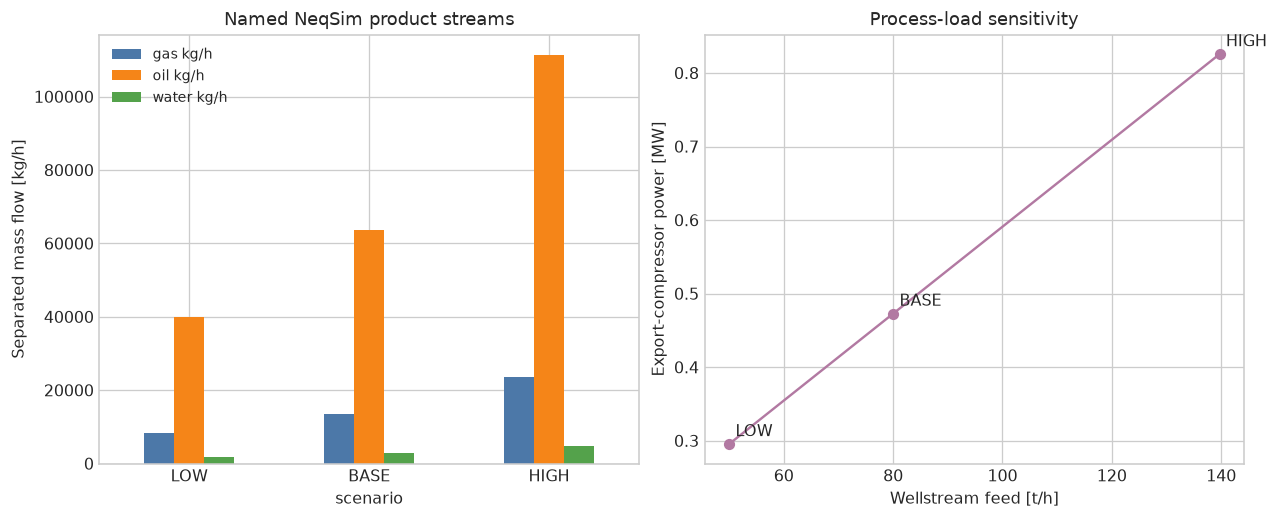

In [13]:
process_figure, process_axes = plt.subplots(
    1,
    2,
    figsize=(11.0, 4.4),
    constrained_layout=True,
)
product_columns = ["gas kg/h", "oil kg/h", "water kg/h"]
process_results.set_index("scenario")[product_columns].plot.bar(
    ax=process_axes[0],
    color=["#4c78a8", "#f58518", "#54a24b"],
)
process_axes[0].set(
    ylabel="Separated mass flow [kg/h]",
    title="Named NeqSim product streams",
)
process_axes[0].tick_params(axis="x", rotation=0)
process_axes[1].plot(
    process_results["feed kg/h"] / 1_000.0,
    process_results["compressor power kW"] / 1_000.0,
    marker="o",
    color="#b279a2",
)
for _, result in process_results.iterrows():
    process_axes[1].annotate(
        result["scenario"],
        (
            result["feed kg/h"] / 1_000.0,
            result["compressor power kW"] / 1_000.0,
        ),
        xytext=(4, 5),
        textcoords="offset points",
    )
process_axes[1].set(
    xlabel="Wellstream feed [t/h]",
    ylabel="Export-compressor power [MW]",
    title="Process-load sensitivity",
)
process_path = OUTPUT_DIRECTORY / "05_neqsim_process_handoff.png"
process_figure.savefig(process_path, dpi=170)
plt.show()

**Figure discussion — NeqSim handoff.** Observation: separated gas, hydrocarbon liquid,
and water all scale with the selected wellstream load, and export-compressor power rises
monotonically from LOW to HIGH. Mechanism: composition and arrival state are fixed here,
so the equilibrium split is nearly proportional to mass rate while compression work scales
with gas throughput. Engineering implication: seismic volume uncertainty becomes process
capacity and power uncertainty only after a governed reservoir/well/SURF handoff.
Recommendation: replace the scaling screen with selected compositional arrival profiles and
rerun the connected process for peak, turndown, late-life, shutdown, and upset conditions.

## 7. Full field-development workflow and decision gates

The table below prevents a common category error: an attractive seismic structure can
support opportunity screening but cannot by itself support a development decision. Each
gate adds calibrated evidence, model ownership, alternatives, uncertainty, and assurance.

The same `case_id` should connect seismic/geomodel realization, PVT model, reservoir case,
well/SURF boundary, process case, cost/schedule case, emissions case, and economic result.
This is what makes later optimization and digital-twin updates auditable.

In [14]:
decision_gate_matrix = pd.DataFrame(
    [
        (
            "DG0 opportunity",
            "SEG-Y geometry, amplitude, regional data",
            "screening structure, fault evidence, volume range",
            "license/apply for access and acquire data",
            "no reserves or development concept",
        ),
        (
            "DG1 feasibility",
            "appraisal wells, depth conversion, petrophysics, PVT",
            "conditioned geomodel and dynamic-model alternatives",
            "mature recovery concepts and appraisal plan",
            "no frozen wells, facilities, or value",
        ),
        (
            "DG2 concept select",
            "OPM Flow ensembles, wells, SURF, NeqSim, cost/schedule",
            "integrated rates, constraints, emissions, risk and value",
            "select concept and capacity philosophy",
            "no detailed design certification",
        ),
        (
            "DG3 define",
            "history match, detailed wells/SURF/process/safety",
            "design basis, operability, assurance and execution plan",
            "investment and execution decision",
            "requires accountable discipline review",
        ),
        (
            "DG4 execute/operate",
            "as-built, drilling, 4-D seismic, surveillance, operations",
            "updated models, forecasts, optimization and integrity",
            "operate, optimize, infill, late life and retire",
            "models never replace measurements or MOC",
        ),
    ],
    columns=[
        "gate",
        "new evidence",
        "integrated model output",
        "decision supported",
        "boundary",
    ],
)
model_handoffs = pd.DataFrame(
    [
        (
            "SEIS-BASE",
            "segyio interpretation",
            "static model",
            "top/base/fault + uncertainty",
        ),
        (
            "RES-BASE",
            "OPM Flow ensemble",
            "wells/SURF",
            "rates/pressure/GOR/water cut",
        ),
        (
            "SURF-BASE",
            "well and network model",
            "NeqSim process",
            "arrival P/T/composition/phase loads",
        ),
        (
            "FAC-BASE",
            "NeqSim ProcessSystem",
            "economics and emissions",
            "products/duties/power/capacity",
        ),
    ],
    columns=["case_id", "producer", "consumer", "contract"],
)
display(decision_gate_matrix)
display(model_handoffs)

,gate,new evidence,integrated model output,decision supported,boundary
0,DG0 opportunity,"SEG-Y geometry, amplitude, regional data","screening structure, fault evidence, volume range",license/apply for access and acquire data,no reserves or development concept
1,DG1 feasibility,"appraisal wells, depth conversion, petrophysic...",conditioned geomodel and dynamic-model alterna...,mature recovery concepts and appraisal plan,"no frozen wells, facilities, or value"
2,DG2 concept select,"OPM Flow ensembles, wells, SURF, NeqSim, cost/...","integrated rates, constraints, emissions, risk...",select concept and capacity philosophy,no detailed design certification
3,DG3 define,"history match, detailed wells/SURF/process/safety","design basis, operability, assurance and execu...",investment and execution decision,requires accountable discipline review
4,DG4 execute/operate,"as-built, drilling, 4-D seismic, surveillance,...","updated models, forecasts, optimization and in...","operate, optimize, infill, late life and retire",models never replace measurements or MOC


,case_id,producer,consumer,contract
0,SEIS-BASE,segyio interpretation,static model,top/base/fault + uncertainty
1,RES-BASE,OPM Flow ensemble,wells/SURF,rates/pressure/GOR/water cut
2,SURF-BASE,well and network model,NeqSim process,arrival P/T/composition/phase loads
3,FAC-BASE,NeqSim ProcessSystem,economics and emissions,products/duties/power/capacity


## Validation, results, and limitations

The evidence ladder is:

1. exact SEG-Y amplitude and derived-volume round-trips with header checks;
2. interpretation error against known synthetic top and base surfaces;
3. physical ordering and finite low/base/high volumetric and forecast cases;
4. NeqSim mass conservation and monotonic process-load response; and
5. explicit boundaries between data handling, specialist models, and decisions.

This is stronger than a syntax-only tutorial, but weaker than calibration against field
data or an independent reservoir/process simulator benchmark.

In [15]:
validation_checks = {
    "input SEG-Y amplitude round-trip is exact": (
        input_roundtrip_error < 1.0e-7
    ),
    "derived SEG-Y amplitude round-trip is exact": (
        discontinuity_roundtrip_error < 1.0e-7
    ),
    "all selected SEG-Y headers are retained": all(
        header_contract.values()
    ),
    "top picker error is below one sample": (
        top_pick_rmse_ms < sample_interval_ms
    ),
    "thickness picker error is below one sample": (
        thickness_pick_rmse_ms < sample_interval_ms
    ),
    "STOIIP scenarios are strictly ordered": np.all(
        np.diff(volumetric_scenarios["STOIIP MSm3"]) > 0.0
    ),
    "forecasts are finite and non-negative": (
        np.isfinite(
            field_forecast.select_dtypes(include=[np.number])
        ).all().all()
        and (
            field_forecast[
                ["oil Sm3/d", "gas MSm3/d", "water Sm3/d"]
            ]
            >= 0.0
        ).all().all()
    ),
    "NeqSim process mass balance closes": (
        process_results["relative mass residual"].max() < 1.0e-8
    ),
    "compressor power rises with feed": (
        process_results.sort_values("feed kg/h")[
            "compressor power kW"
        ].is_monotonic_increasing
    ),
    "all five field-development gates are represented": (
        len(decision_gate_matrix) == 5
    ),
    "all five static figures were saved": all(
        path.is_file()
        for path in [
            quicklook_path,
            attribute_path,
            interpretation_path,
            forecast_path,
            process_path,
        ]
    ),
}
validation_table = pd.DataFrame(
    {
        "check": validation_checks.keys(),
        "passed": validation_checks.values(),
    }
)
display(validation_table)
failed_checks = validation_table.loc[
    ~validation_table["passed"],
    "check",
].tolist()
if failed_checks:
    raise AssertionError(f"Failed checks: {failed_checks}")

base_volume = volumetric_scenarios.set_index("scenario").loc["BASE"]
base_process = process_results.set_index("scenario").loc["BASE"]
result_summary = pd.DataFrame(
    {
        "result": [
            "top pick RMSE",
            "thickness pick RMSE",
            "LOW / BASE / HIGH STOIIP",
            "BASE recoverable oil",
            "BASE process feed",
            "BASE compressor power",
            "maximum NeqSim mass residual",
        ],
        "value": [
            top_pick_rmse_ms,
            thickness_pick_rmse_ms,
            " / ".join(
                f"{value:.2f}"
                for value in volumetric_scenarios["STOIIP MSm3"]
            ),
            base_volume["recoverable MSm3"],
            base_process["feed kg/h"],
            base_process["compressor power kW"],
            process_results["relative mass residual"].max(),
        ],
        "unit": [
            "ms",
            "ms",
            "MSm³",
            "MSm³",
            "kg/h",
            "kW",
            "fraction",
        ],
    }
)
display(result_summary)
print(f"All {len(validation_checks)} validation checks passed.")

All 11 validation checks passed.


,check,passed
0,input SEG-Y amplitude round-trip is exact,True
1,derived SEG-Y amplitude round-trip is exact,True
2,all selected SEG-Y headers are retained,True
3,top picker error is below one sample,True
4,thickness picker error is below one sample,True
5,STOIIP scenarios are strictly ordered,True
6,forecasts are finite and non-negative,True
7,NeqSim process mass balance closes,True
8,compressor power rises with feed,True
9,all five field-development gates are represented,True


,result,value,unit
0,top pick RMSE,2.313,ms
1,thickness pick RMSE,1.286,ms
2,LOW / BASE / HIGH STOIIP,5.17 / 11.50 / 20.08,MSm³
3,BASE recoverable oil,3.91,MSm³
4,BASE process feed,8e+04,kg/h
5,BASE compressor power,472.8,kW
6,maximum NeqSim mass residual,4.084e-14,fraction


## What to do next in NeqSim-Colab

1. Continue with
   [`subsurface_data_to_opm_flow_production_forecast.ipynb`](../reservoir/subsurface_data_to_opm_flow_production_forecast.ipynb)
   for LAS, core/SCAL, geomodelling, upscaling, NeqSim PVT, and OPM Flow.
2. Use
   [`rock_derived_productivity_injectivity_opm_neqsim.ipynb`](../well/rock_derived_productivity_injectivity_opm_neqsim.ipynb)
   for pressure-to-rate inflow and injection constraints.
3. Use
   [`complete_oil_and_gas_value_chain_with_neqsim.ipynb`](../valuechain/complete_oil_and_gas_value_chain_with_neqsim.ipynb)
   for facilities, products, emissions, value, RAM, late life, and retirement.
4. Replace the synthetic cube with governed public or project SEG-Y only after recording
   license, CRS, sample units, processing history, interpretation version, and uncertainty.

**Suggested exercises**

- Re-read the public F3 tutorial files and compare the simple gradient attribute with its
  supplied similarity volume.
- Vary the fault threshold and quantify the change in compartment area and STOIIP.
- Replace the constant velocity with low/base/high depth-conversion grids.
- Generate OPM Flow fault-transmissibility cases rather than assuming a sealed boundary.
- Feed selected OPM Flow well histories into NeqSim instead of scaling one composition.
- Optimize appraisal information value before adding wells or process capacity.

No NeqSim library defect or missing public API was found while building this notebook.
The principal limitations are intentionally outside NeqSim: seismic interpretation,
depth conversion, geomodelling, dynamic reservoir simulation, and detailed multiphase flow.